# Project Sample

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Read Data - Tables from internet

To allow google colab to pull your file from your google drive first click the "Share" option on the file
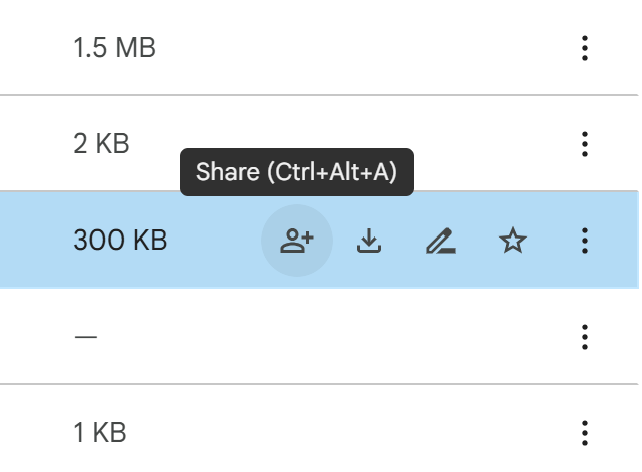

From there change the General Access from "Restricted" to "Anyone with the link"
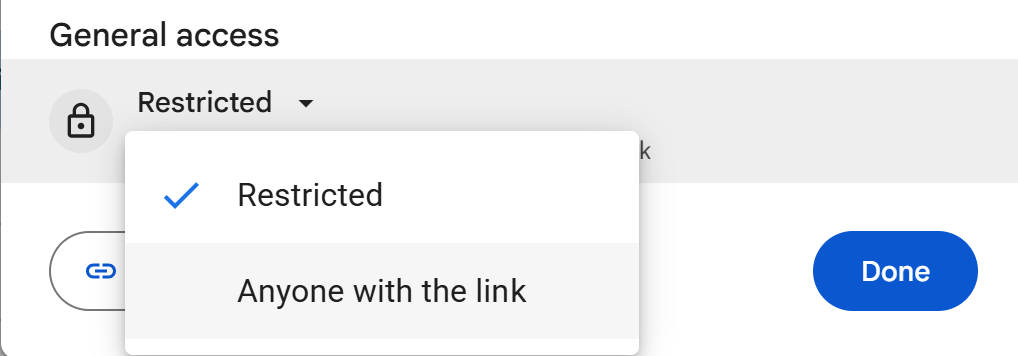

Next click the "Copy link" option to get the link for your file
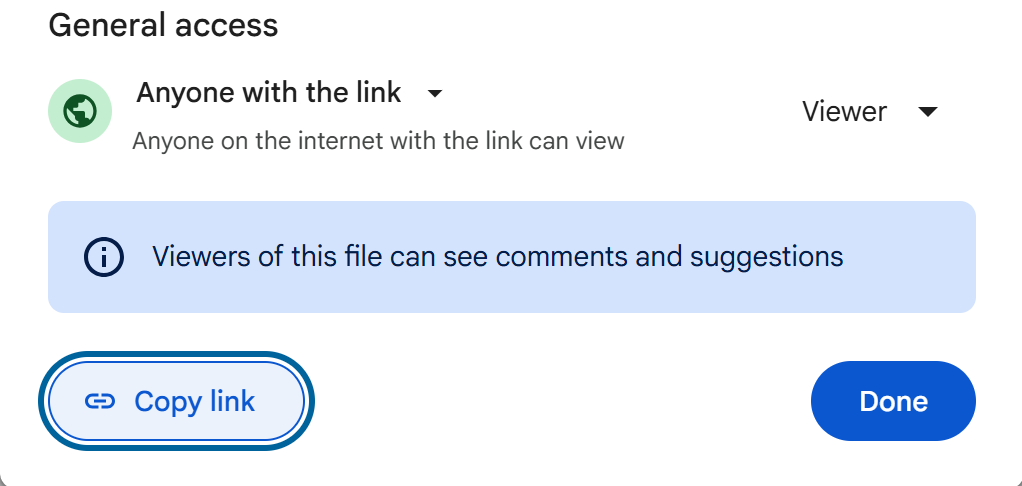

You do not need the whole string from the link, just the the section in the middle. For example, in the link https://drive.google.com/file/d/1sCEQsdfw1-JsuugJMgDuxcq4iUvqAI1f/view?usp=sharing the only thing that is needed is <br>
1sCEQsdfw1-JsuugJMgDuxcq4iUvqAI1f

Finally, follow the example below, but with your unique string of characters and colab will download the file into the session for use

In [ ]:
#CSV File
!gdown 1sCEQsdfw1-JsuugJMgDuxcq4iUvqAI1f

# Manual Analysis

In [6]:
def CSV_Data_Reader(File_Name, Seprator, NonNumerical):
  '''
  This function takes a csv file and generates a dictionary
  The keys of the dictionary are the column names
  Values of the dictionary are columns of the data
  '''
  import csv
  with open(File_Name) as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=Seprator)
    line_count=0
    Data=[]
    for row in csv_reader:
      if line_count==0:
        Header=row
      else:
        Data.append(row)
      line_count=line_count+1

  Data_dict={}

  idx=0
  for name in Header:
    Data_dict[name]=[]
    for row in Data:
      if name in NonNumerical:
        Data_dict[name].append(row[idx])
      else:
        if row[idx].replace('.','').isdigit():
          Data_dict[name].append(float(row[idx]))
        else:
          Data_dict[name].append(None)
    idx=idx+1
  return Data_dict

Save the data from our CSV file into a variable

In [7]:
Data=CSV_Data_Reader('/content/AI_030_JM_Data_All.csv',',',['DateTime'])

In [ ]:
for i in Data:
  print(i)

Filter the data to only have the first 25 columns where the first letter begins with 'T' 'S' or 'D'

In [5]:
DataCut={}

q=0
for i in Data:
  q=q+1
  if q <25:
    if i[0]=='T' or i[0]=='S' or i[0]=='D':
      DataCut[i]=Data[i]


In [ ]:
for i in DataCut:
  print(i)

Currently our date time is combining day month year and time of day into one value

In [ ]:
DataCut['DateTime'][0]

### Parse DateTime - Time series

Now we're going to split the date time into the individual values

In [8]:
import datetime

In [9]:
datetime.datetime.strptime(DataCut['DateTime'][0], '%m/%d/%Y %H:%M')

datetime.datetime(2008, 9, 5, 17, 2)

In [ ]:
datetime.datetime.strptime(DataCut['DateTime'][0], '%m/%d/%Y %H:%M').month

In [11]:
q=0
for i in DataCut['DateTime']:
  DataCut['DateTime'][q]=datetime.datetime.strptime(i, '%m/%d/%Y %H:%M')
  q=q+1

Now we have all of our date times saved with each individual value in the order year, month, day, hour, minute. This will let us more easily grab our relevant data based on the specific time frames that we need.

In [ ]:
DataCut['DateTime'][0]

Additionally, if I want to access a specific value I can add '.*value*' to the end to get specifically that value. For example '.month' will give just the month value and '.year' will give just the year value.

In [ ]:
DataCut['DateTime'][0].month

##Create Plots

We can generate a basic scatter plot showing all of our values in S1 over time

In [ ]:
plt.scatter(DataCut['DateTime'], DataCut['S1'])

In [ ]:
plt.hist(DataCut['S1'])

That didn't work because out file still has NULL values present. We need to filter the data to only use real values.

In [16]:
S1=[]
for i in DataCut['S1']:
  if i!=None:
    S1.append(i)


Now we're able to generate our histogram

In [ ]:
plt.hist(S1)

Additionally, I can add some extra logic to have it only append the values within the specific time frame that I want, in this case where the month is 9, aka September.

In [ ]:
S1=[]
count = 0
for i in DataCut['S1']:
  if i!=None:
    if DataCut['DateTime'][count].month == 9:
      S1.append(i)
  count += 1

plt.hist(S1)

## Shrink Data

Now lets clean the data even more. Before DataCut just had the columns we wanted to use. Now we want it to have those columns, but also remove the unusable values for DateTime, S1, and T1, as these are the specific columns needed for what we're evaluating.

In [19]:
DataCutCleanCut={'DateTime':[],'S1':[],'Temp1':[] }

for i in range(len(DataCut['DateTime'])):
  if DataCut['DateTime'][i]!=None and DataCut['S1'][i]!=None and DataCut['Temp1'][i]!=None:
    DataCutCleanCut['DateTime'].append(DataCut['DateTime'][i])
    DataCutCleanCut['S1'].append(DataCut['S1'][i])
    DataCutCleanCut['Temp1'].append(DataCut['Temp1'][i])



In [ ]:
for i in DataCutCleanCut:
  print(i)

In [ ]:
len(DataCutCleanCut['DateTime'])

## Moving Stats

Next, lets try grouping our data to be able to more easily access values from specific months. We can start by making a list containing all of the month values.

In [ ]:
Month=list(range(1,13))

print(Month)

Next, we can create the empty dictionary that will later be populated with the appropriate values.

In [23]:
DataGrouped={'Month':Month, 'S1':[[] for i in range(12)], 'Temp1':[[] for i in range(12)]}

Now for each value in our cleaned data it will go to each month and save the entries based on the month that they were recorded in.

In [25]:
for index in range(len(DataCutCleanCut['DateTime'])):
  #print(index)
  for m in Month:
   #print(m)
   if DataCutCleanCut['DateTime'][index].month==m:
     #print(m)
     DataGrouped['S1'][m-1].append(DataCutCleanCut['S1'][index])
     DataGrouped['Temp1'][m-1].append(DataCutCleanCut['Temp1'][index])
     break

Now we can see that the length of DataGrouped['S1'] is 12, one for each month

In [ ]:
len(DataGrouped['S1'])

And by using length after filtering by month be can see the number of entries within that month.

In [ ]:
len(DataGrouped['S1'][0])

In [ ]:
len(DataGrouped['S1'][11])

Now we can create an empty dictionary for us to use to hold our relevant stats.

In [58]:
Stats={'Month':Month, 'S1_AVG':[], 'Temp1_Max':[], 'Count':[]}

This code then iterates over all months and adds the average value of S1 in that month to the list containing the S1 averages.

In [59]:
for i in range(12):
  Stats['S1_AVG'].append(sum(DataGrouped['S1'][i])/len(DataGrouped['S1'][i]))

In [ ]:
Stats

Now try it yourself by populating the Temp1_Max and Count lists with the appropriate data.

Hint: You can use max() to find the largest value from a list and len() to find the amount of values in a list.

In [61]:
#Complete the code!





#Pandas Verification

Using Pandas we can immediately import the csv to a variable and have all our data organized into their respective columns.

In [ ]:
df_RAW=pd.read_csv('/content/AI_030_JM_Data_All.csv')

In [ ]:
df_RAW

In [ ]:
list(df_RAW.columns)

In [ ]:
df_RAW.index

In [ ]:
df_RAW.info(verbose=True)#use verbose to show all columns

.describe() also lets us quickly see some important statistics about each column

In [ ]:
df_RAW.describe()

In [ ]:
df_RAW.columns[0:25]

By using .copy() we can have a new variable that only contains the first 25 columns of data

In [ ]:
df=df_RAW[df_RAW.columns[0:25]].copy()
df.tail(6)

Next we can use .drop() to remove the rest of the columns we don't care about

In [ ]:
df.drop(df.columns[1:11],axis=1).head()

In [ ]:
df=df.drop(df.columns[1:11],axis=1)
df

Finally we can rename the columns to something that we prefer

In [ ]:
['DateTime']+['Sensor'+str(i) for i in range(7)]+['Temperature'+str(i) for i in range(7)]

In [74]:
df.columns=['DateTime']+['Sensor'+str(i) for i in range(7)]+['Temperature'+str(i) for i in range(7)]

In [ ]:
df.head()

### Parse Date Time - Time series

Pandas has a built in method to convert our date time into a proper date time that lets us pull out the individual values we need

In [ ]:
df.info()

In [ ]:
df['DateTime']

pd.to_datetime(*data*) automatically converts the date time on its own

In [ ]:
pd.to_datetime(df['DateTime'])

In [79]:
dfc=df.copy()
df['DateTime']=pd.to_datetime(df['DateTime'])

You can see after changing df the type for DateTime is now datetime64, while the unchanged dfc DateTime is an object

In [ ]:
df.info()

In [ ]:
dfc.info()

In [ ]:
dfc['DateTime']

Another method we can use with pd.datetime() is specifying the format if we so choose

In [ ]:
pd.to_datetime(dfc['DateTime'], format='%m/%d/%Y %H:%M')

<font color='magenta[link text](https://)'>Where should I get the formatting?!</font><br>
https://docs.python.org/3/library/datetime.html

In [ ]:
df.info()

Now that we have our date time properly set up we can access the specific values we need from it

In [ ]:
df['DateTime'].dt.year#year,month,day,hour,minute,second

In [ ]:
df.tail()

We can also use it for filtering, for example all values where the minute is either 00 or 30

In [ ]:
df[(df['DateTime'].dt.minute==00) | (df['DateTime'].dt.minute==30)]

## Pre-Processing

There are multiple terms that are ultimately used to convey the same info, namely that a current data point has no actual data

In [ ]:
None
np.nan
pd.NA

### Gap in Data
Empty cell! <br>
*   Python: None
*   Numpy: NaN (np.nan)
*  Pandas: NA (pd.NA)
*   SQL: NULL



In [ ]:
df.head()

In [ ]:
df.info()

Pandas has a built in method to check if a given data point is currently null

In [ ]:
df.notnull()#notnull

Simply removing all null values won't ensure clean data though, as there could be outliers, so the question is how do we want to deal with these types of data points?

####Treat outliers like Gaps?!
Only outliers that are like NaN

In [ ]:
df[df['Sensor1'].notnull()]

We can check our data to see what these outliers are and update them to now be empty values

In [ ]:
df.replace(-99999,None).head(10)

In [ ]:
df=df.replace(-99999,None)
df

We can then repeat the process but with Temperature

In [ ]:
df['Temperature0'].min()

In [ ]:
df[df['Temperature1']==-99.99]

In [94]:
df=df.replace(-99.99,None)

In [ ]:
df

Note that now we have our data frame with both NaN and None values. While both convey the lack of useful data present, we can choose how to handle each case separately

#### Remove the records (rows) with NaN Values

In [ ]:
df

The thresh parameter is the amount of columns in that row that need to have a value of NaN for it to be dropped

In [ ]:
df.dropna(thresh=5,subset=['Sensor'+str(i) for i in range(7)])

In [ ]:
df.dropna(axis=1, thresh=100)#remove the columns

In [99]:
df=df.dropna(thresh=5,subset=['Sensor'+str(i) for i in range(7)])

In [ ]:
df

In [ ]:
df=df.dropna(thresh=3,subset=['Temperature'+str(i) for i in range(7)])
df

We have now removed the bulk of the unusable values while still retaining as much usable data as possible

#### Fill the gap

We still would rather not have null values present in our data so now we can choose how to handle them

fillna(0) will replace all the null values with a 0, however doing this will also skew our data when it comes to finding the mean

In [ ]:
df.fillna(0)

In [ ]:
df.fillna(df.mean()) #What about mean?

Instead Pandas has a method called interpolate that will do its best to look at the surrounding data and estimate what the missing value **should** be

In [ ]:
#df['Sensor2'].loc[607]=None
#df
df.interpolate(method='linear') #Remember Axis is zero by default

In [ ]:
df=df.interpolate(method='linear') #Remember Axis is zero by default
df=df.dropna(thresh=7,subset=['Sensor'+str(i) for i in range(7)])
df

Now we have clean usable values for all of our sensor columns

### Combine Columns (Series)
In this case, all thermistors are so close so we want to use the mean of them all

In [ ]:
df

In [ ]:
df.columns[-7:]

In [ ]:
df[df.columns[-7:]].mean(axis=1)

In [109]:
df['Temperature']=df[df.columns[-7:]].mean(axis=1)

In [ ]:
df.columns

In [ ]:
df.columns[-8:-1]

In [ ]:
df=df.drop(df.columns[-8:-1],axis=1)
df

Now we have condensed all of our temperatures into one column as their values were already rather similar

###Re-Sampling
Read more: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html

##### Dont confuse it with sampling!!

If we would like to we can use resampling to help group our data by every 30 minutes and condense our data

In [ ]:
df.sample(10) #randomly select 10 records
#df.sample(frac=0.1) #or randomly select some percentage of data

In [ ]:
df.sample(frac=0.1)

In [ ]:
df.resample('30min',on='DateTime').max()#min, y,d


In [ ]:
df.set_index('DateTime').resample('30min').mean()

We can also use resampling to group our data by certain time frames like weeks

In [ ]:
df_Weekly=df.resample('7d',on='DateTime').mean()
df_Weekly

Now that we have our weekly data we can use that to make a plot

In [ ]:
df_Weekly.drop(['Temperature','Sensor6'],axis=1).plot()

### Query - Data Grouping/Selection

In [ ]:
df

Pandas offers an easy way to get the average value based on month

In [ ]:
df.groupby(by=df['DateTime'].dt.month).mean()

We can also use it to easily plot our average values for everything by month and year

In [ ]:
df.groupby(by=[df['DateTime'].dt.year,df['DateTime'].dt.month] ).mean().plot()

In [ ]:
df.info()